In [1]:
# ============================================================
# 1) Import required libraries
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from imblearn.over_sampling import SMOTENC

from sklearn import svm, tree
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import ExtraTreesClassifier, AdaBoostClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

In [2]:
# ============================================================
# 2) Load and clean data
# ============================================================

df0 = pd.read_csv("diabetes_prediction_dataset.csv")
print("Head of raw data:")
print(df0.head(10))

print("\nColumns:", df0.columns.to_list())
print("\nDtypes:")
print(df0.dtypes)
print("\nTarget distribution (raw):")
print(df0["diabetes"].value_counts())

if np.sum(df0.duplicated() == True) != 0:
    df0 = df0.drop_duplicates()

if df0.isnull().sum().sum() != 0:
    df0 = df0.dropna()

print("\nGender value counts (before cleaning):")
print(df0["gender"].value_counts())

df0 = df0[df0["gender"] != "Other"].copy()

df0["gender"].replace({"Female": 0, "Male": 1}, inplace=True)

print("\nSmoking_history value counts (raw):")
print(df0["smoking_history"].value_counts())

def recategorize_smoking(smoking_status):
    """Map original smoking_history values into 3 macro categories."""
    if smoking_status in ["never", "No Info"]:
        return "non-smoker"
    elif smoking_status == "current":
        return "current"
    elif smoking_status in ["ever", "former", "not current"]:
        return "past_smoker"
    else:
        return np.nan

df0["smoking_history"] = df0["smoking_history"].apply(recategorize_smoking)
df0 = df0.dropna().copy()

print("\nHead after gender/smoking recoding:")
print(df0.head(10))

Head of raw data:
   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0             0              1           never  25.19   
1  Female  54.0             0              0         No Info  27.32   
2    Male  28.0             0              0           never  27.32   
3  Female  36.0             0              0         current  23.45   
4    Male  76.0             1              1         current  20.14   
5  Female  20.0             0              0           never  27.32   
6  Female  44.0             0              0           never  19.31   
7  Female  79.0             0              0         No Info  23.86   
8    Male  42.0             0              0           never  33.64   
9  Female  32.0             0              0           never  27.32   

   HbA1c_level  blood_glucose_level  diabetes  
0          6.6                  140         0  
1          6.6                   80         0  
2          5.7                  158         0  
3       

In [3]:
# ============================================================
# 3) One-Hot encoding for smoking_history
# ============================================================

try:
    ohe = OneHotEncoder(sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(sparse=False)

mct = make_column_transformer(
    (ohe, ["smoking_history"]),
    remainder="passthrough",
)

df1 = pd.DataFrame(
    mct.fit_transform(df0),
    columns=[
        "current",
        "non-smoker",
        "past_smoker",
        "gender",
        "age",
        "hypertension",
        "heart_disease",
        "bmi",
        "HbA1c_level",
        "blood_glucose_level",
        "diabetes",
    ],
)

df1 = df1.astype(float)

print("\nHead of processed dataframe (df1):")
print(df1.head(10))

print("\nSummary of main continuous features:")
print(df1[["age", "bmi", "HbA1c_level", "blood_glucose_level"]].describe())


Head of processed dataframe (df1):
   current  non-smoker  past_smoker  gender   age  hypertension  \
0      0.0         1.0          0.0     0.0  80.0           0.0   
1      0.0         1.0          0.0     0.0  54.0           0.0   
2      0.0         1.0          0.0     1.0  28.0           0.0   
3      1.0         0.0          0.0     0.0  36.0           0.0   
4      1.0         0.0          0.0     1.0  76.0           1.0   
5      0.0         1.0          0.0     0.0  20.0           0.0   
6      0.0         1.0          0.0     0.0  44.0           0.0   
7      0.0         1.0          0.0     0.0  79.0           0.0   
8      0.0         1.0          0.0     1.0  42.0           0.0   
9      0.0         1.0          0.0     0.0  32.0           0.0   

   heart_disease    bmi  HbA1c_level  blood_glucose_level  diabetes  
0            1.0  25.19          6.6                140.0       0.0  
1            0.0  27.32          6.6                 80.0       0.0  
2            0.0

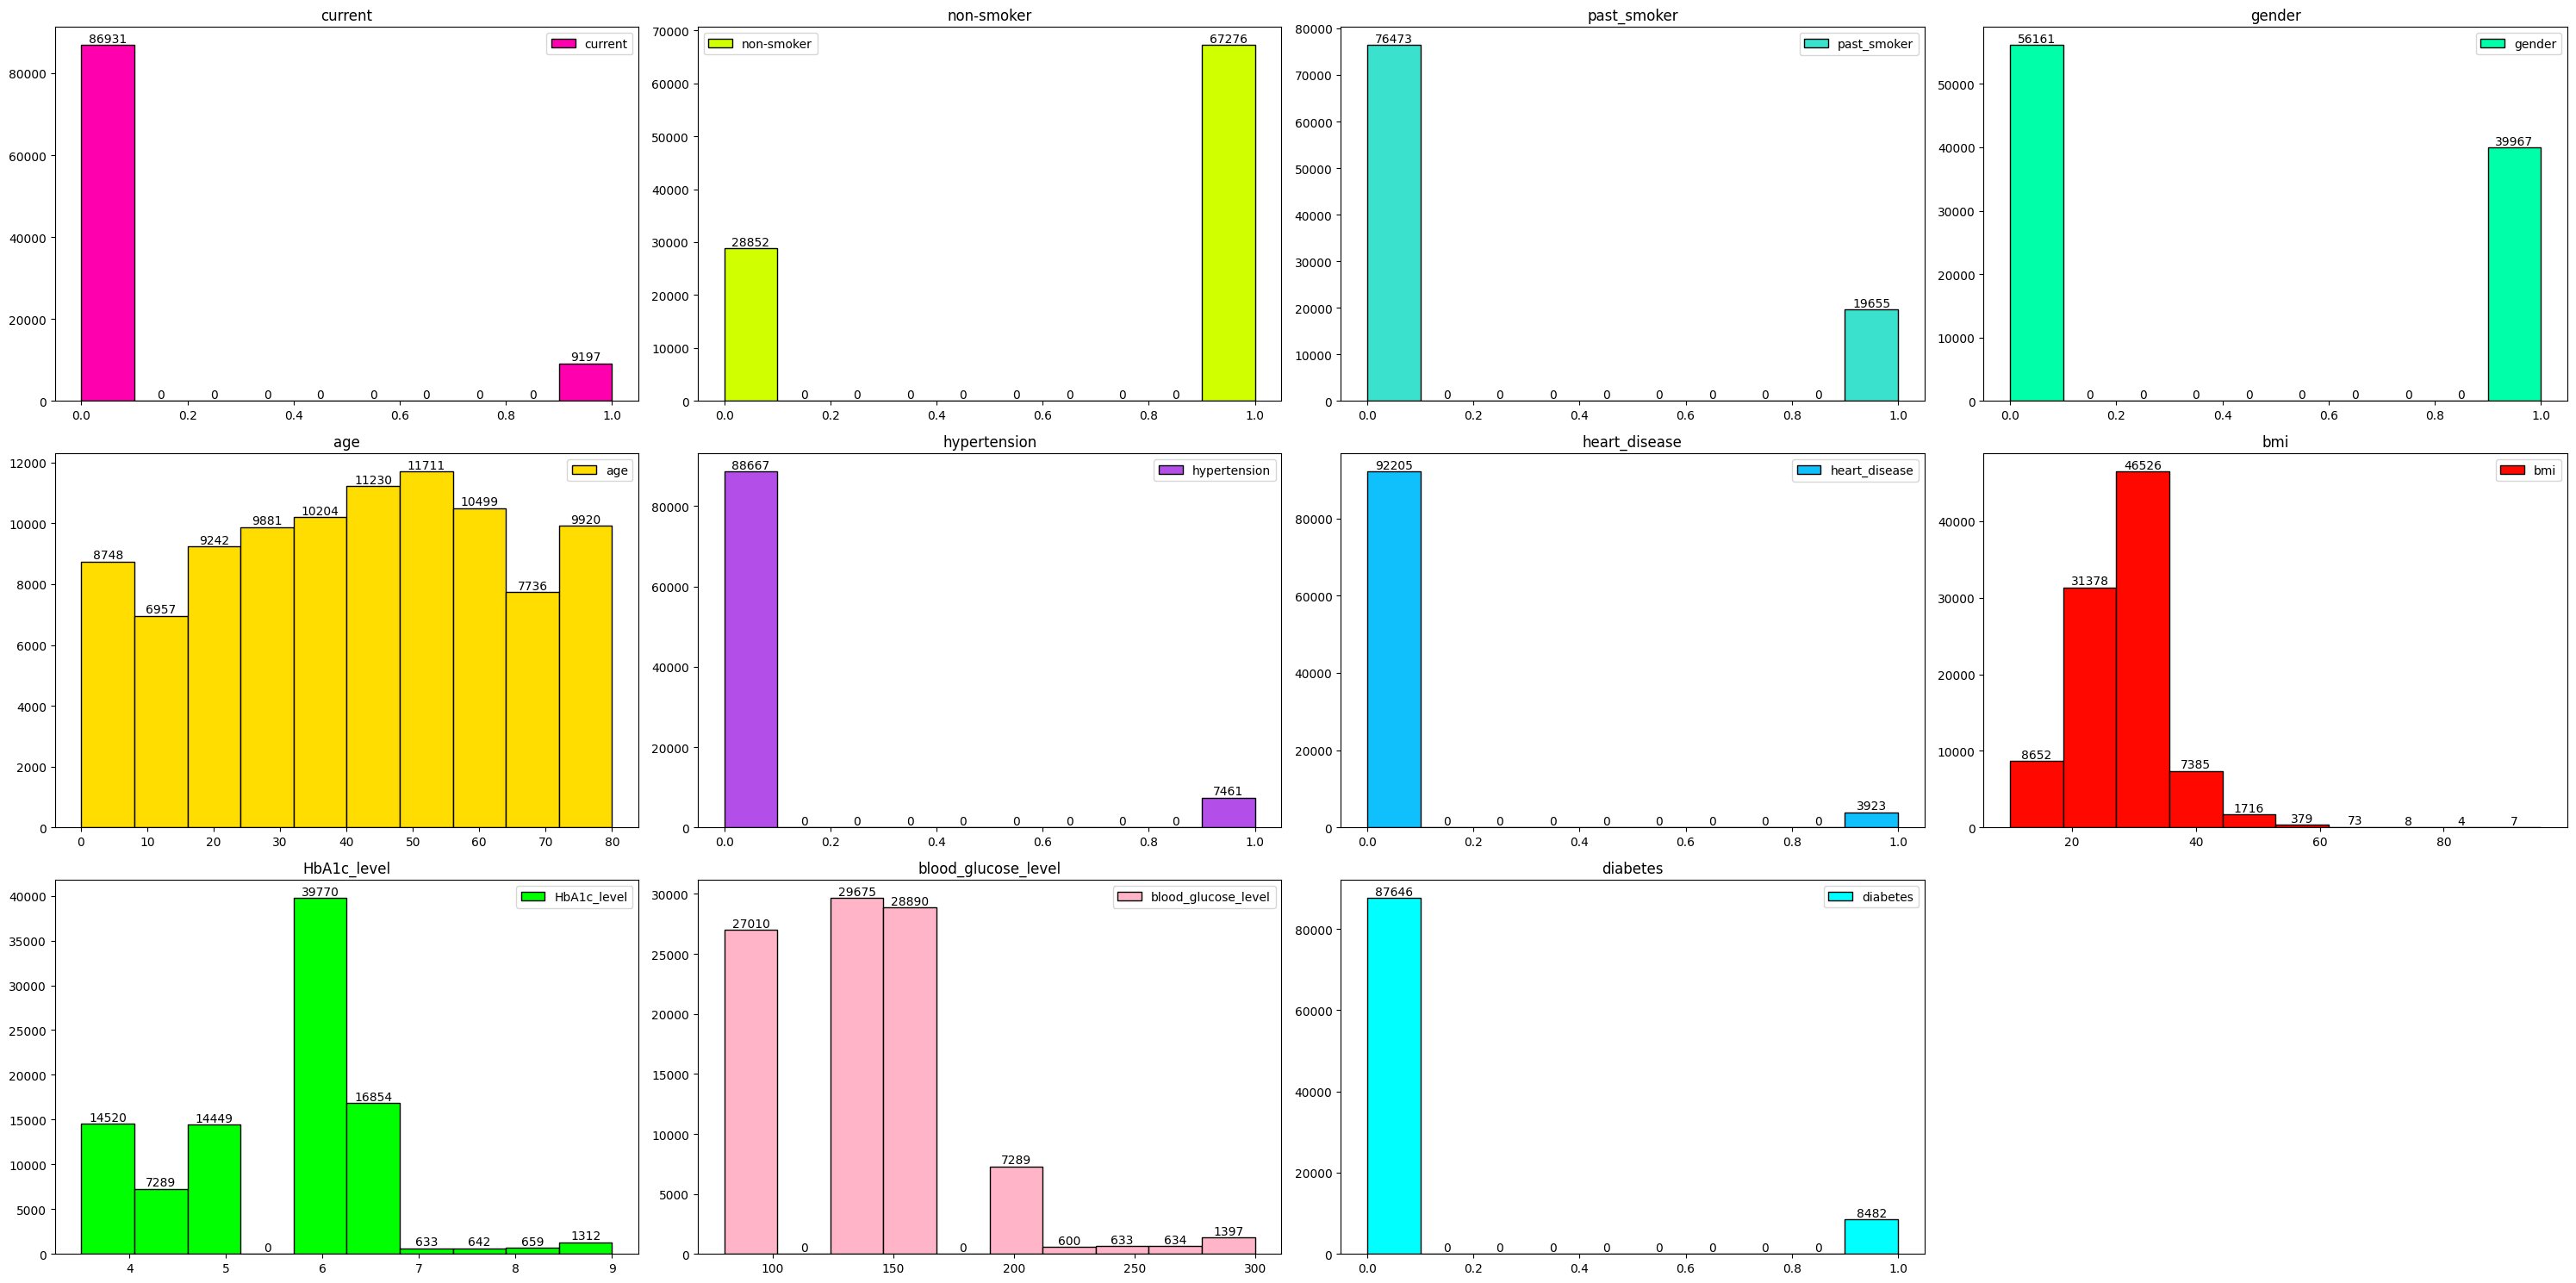

In [4]:
# ============================================================
# 4) Histograms for all features (visual EDA)
# ============================================================

plt.figure(figsize=(30, 15))
try:
    colors = [
        "#FF00AE",
        "#D0FF00",
        "#3AE2CE",
        "#00FFA9",
        "#FFDD00",
        "#B34EE9",
        "#0FC0FC",
        "#FF0800",
        "#00FF00",
        "#FFB4C8",
        "#00FFFF",
    ]
    for i, col in enumerate(df1.columns.to_list()):
        plt.subplot(3, 4, i + 1)
        freq, bins, patches = plt.hist(
            df1[col], label=col, color=colors[i], edgecolor="black"
        )
        bin_centers = np.diff(bins) * 0.5 + bins[:-1]
        n = 0
        for fr, x, patch in zip(freq, bin_centers, patches):
            height = int(freq[n])
            plt.annotate(
                "{}".format(height),
                xy=(x, height),
                xytext=(0, 0.2),
                textcoords="offset points",
                ha="center",
                va="bottom",
            )
            n += 1
        plt.legend()
        plt.title(col)
        plt.tight_layout()
except Exception as e:
    print(col, e)
plt.show()

In [5]:
# ============================================================
# 5) Convert to NumPy, split, scaling, SMOTENC
# ============================================================

smoking_map = {
    "current": 0,
    "non-smoker": 1,
    "past_smoker": 2,
}

df_model = df0.copy()
df_model["smoking_code"] = df_model["smoking_history"].map(smoking_map)

X_raw = df_model[
    [
        "smoking_code",
        "gender",
        "age",
        "hypertension",
        "heart_disease",
        "bmi",
        "HbA1c_level",
        "blood_glucose_level",
    ]
].to_numpy(dtype=float)

Y = df_model["diabetes"].to_numpy(dtype=int)

X_train_raw, X_test_raw, Y_train, Y_test = train_test_split(
    X_raw, Y, random_state=42, test_size=0.25, stratify=Y
)

print("\nTrain/Test shapes before SMOTENC:")
print("X_train:", X_train_raw.shape, "X_test:", X_test_raw.shape)

scaler = StandardScaler()
continuous_cols = [2, 5, 6, 7]

scaler.fit(X_train_raw[:, continuous_cols])
X_train_raw[:, continuous_cols] = scaler.transform(X_train_raw[:, continuous_cols])
X_test_raw[:, continuous_cols] = scaler.transform(X_test_raw[:, continuous_cols])

categorical_features = [0, 1, 3, 4]

sm = SMOTENC(categorical_features=categorical_features, random_state=42)
X_train_raw, Y_train = sm.fit_resample(X_train_raw, Y_train)

Y_train = Y_train.astype(int)
Y_test = Y_test.astype(int)

print("X_train after SMOTENC:", X_train_raw.shape)

def build_final_features(X_data):
    smoking = np.rint(X_data[:, 0]).astype(int)
    smoking = np.clip(smoking, 0, 2)

    smoking_ohe = np.zeros((X_data.shape[0], 3))
    smoking_ohe[np.arange(X_data.shape[0]), smoking] = 1

    X_final = np.column_stack(
        (
            smoking_ohe[:, 0],
            smoking_ohe[:, 1],
            smoking_ohe[:, 2],
            X_data[:, 1],
            X_data[:, 2],
            X_data[:, 3],
            X_data[:, 4],
            X_data[:, 5],
            X_data[:, 6],
            X_data[:, 7],
        )
    )

    return X_final.astype(float)

X_train = build_final_features(X_train_raw)
X_test = build_final_features(X_test_raw)


Train/Test shapes before SMOTENC:
X_train: (72096, 8) X_test: (24032, 8)
X_train after SMOTENC: (131468, 8)


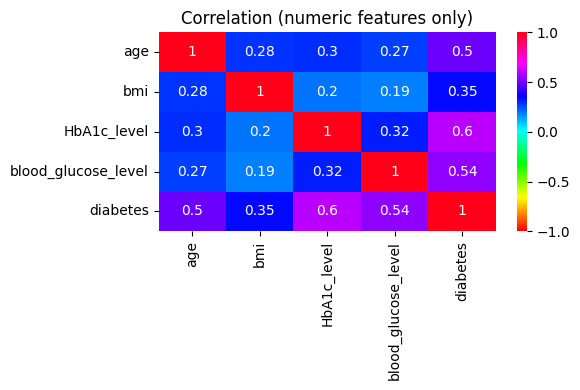


Correlation of numeric features with diabetes:
diabetes               1.000000
HbA1c_level            0.598695
blood_glucose_level    0.541330
age                    0.498907
bmi                    0.348172
Name: diabetes, dtype: float64


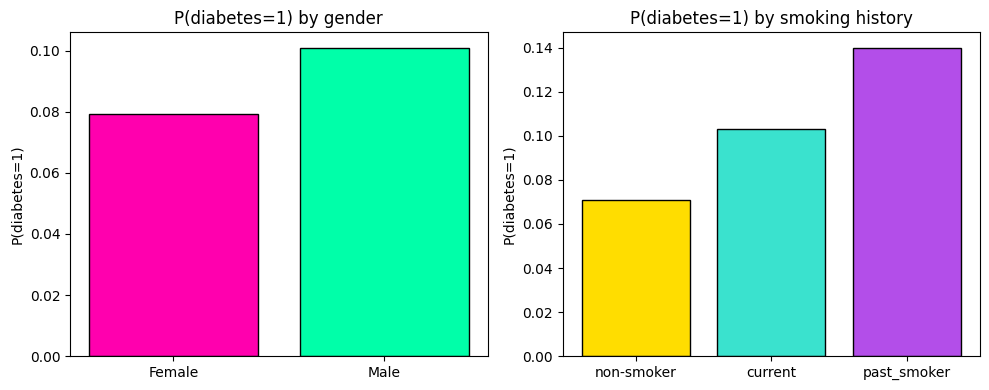

In [6]:
# ============================================================
# 6) Correlation and categorical analysis
# ============================================================

df_train_full = pd.DataFrame(
    np.concatenate((X_train, Y_train[:, None]), axis=1),
    columns=[
        "current",
        "non-smoker",
        "past_smoker",
        "gender",
        "age",
        "hypertension",
        "heart_disease",
        "bmi",
        "HbA1c_level",
        "blood_glucose_level",
        "diabetes",
    ],
)

numeric_cols = ["age", "bmi", "HbA1c_level", "blood_glucose_level", "diabetes"]
corr_numeric = df_train_full[numeric_cols].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr_numeric, cmap="hsv", vmin=-1, vmax=1, annot=True)
plt.title("Correlation (numeric features only)")
plt.tight_layout()
plt.show()

print("\nCorrelation of numeric features with diabetes:")
print(corr_numeric["diabetes"].sort_values(ascending=False))

gender_means = df0.groupby("gender")["diabetes"].mean()
smoking_means = df0.groupby("smoking_history")["diabetes"].mean()

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.bar(
    ["Female", "Male"],
    [gender_means.loc[0], gender_means.loc[1]],
    color=["#FF00AE", "#00FFA9"],
    edgecolor="black",
)
plt.title("P(diabetes=1) by gender")
plt.ylabel("P(diabetes=1)")

labels = ["non-smoker", "current", "past_smoker"]
values = [
    smoking_means.loc["non-smoker"],
    smoking_means.loc["current"],
    smoking_means.loc["past_smoker"],
]

plt.subplot(1, 2, 2)
plt.bar(
    labels,
    values,
    color=["#FFDD00", "#3AE2CE", "#B34EE9"],
    edgecolor="black",
)
plt.title("P(diabetes=1) by smoking history")
plt.ylabel("P(diabetes=1)")

plt.tight_layout()
plt.show()


Important features (index > mean importance): ['4', '8', '9']
Shape after feature selection: Xtr: (131468, 3) Xte: (24032, 3)

ExtraTrees feature importances:
Feature: 0, Score: 0.00146
Feature: 1, Score: 0.00511
Feature: 2, Score: 0.00596
Feature: 3, Score: 0.00660
Feature: 4, Score: 0.18690
Feature: 5, Score: 0.03697
Feature: 6, Score: 0.01694
Feature: 7, Score: 0.09150
Feature: 8, Score: 0.35044
Feature: 9, Score: 0.29812


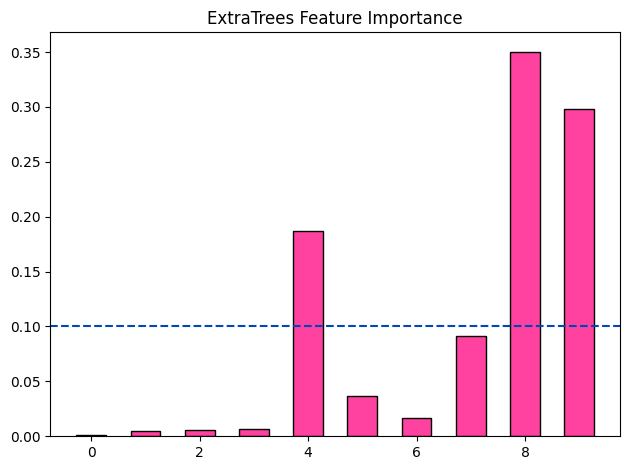

In [7]:
# ============================================================
# 7) Feature importance with ExtraTrees (embedded selection)
# ============================================================

clf = ExtraTreesClassifier(n_estimators=100, random_state=42)
clf = clf.fit(X_train, Y_train)

model = SelectFromModel(clf, prefit=True, threshold="mean")
Xtr = model.transform(X_train)
Xte = model.transform(X_test)
Ytr = Y_train
Yte = Y_test

importance = clf.feature_importances_
selected_mask = model.get_support()
important_features = [str(i) for i, selected in enumerate(selected_mask) if selected]

print("\nImportant features (index > mean importance):", important_features)

print("Shape after feature selection: Xtr:", Xtr.shape, "Xte:", Xte.shape)

print("\nExtraTrees feature importances:")
for i, v in enumerate(importance):
    print("Feature: %0d, Score: %.5f" % (i, v))

plt.bar(
    [x for x in range(len(importance))],
    importance,
    color="#FF41A0",
    edgecolor="black",
    width=0.55,
)
plt.axhline(np.mean(importance), color="#0048BA", linestyle="--")
plt.title("ExtraTrees Feature Importance")
plt.tight_layout()
plt.show()

In [8]:
# ============================================================
# 8) Helper for storing and showing classifier progress
# ============================================================

results = []

def add_result(name, train_acc, test_acc):
    """Store model performance."""
    results.append(
        {"model": name, "train_acc": train_acc, "test_acc": test_acc}
    )

def show_overall_progress():
    """Show a compact table of all models so far."""
    if not results:
        return
    df_res = pd.DataFrame(results)
    best = df_res["test_acc"].max()
    df_res["relative_to_best"] = (df_res["test_acc"] / best).round(3)
    print("\n=== Overall classifier results so far ===")
    print(df_res)
    print("=========================================\n")


>>> Training GaussianNB...
GaussianNB - Train acc: 0.8556911187513311  Test acc: 0.8766228362183754
              precision    recall  f1-score   support

           0       0.98      0.88      0.93     21912
           1       0.40      0.82      0.54      2120

    accuracy                           0.88     24032
   macro avg       0.69      0.85      0.73     24032
weighted avg       0.93      0.88      0.89     24032


=== Overall classifier results so far ===
        model  train_acc  test_acc  relative_to_best
0  GaussianNB   0.855691  0.876623               1.0



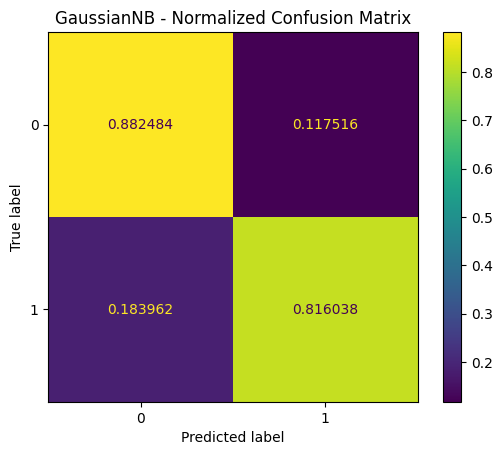

In [9]:
# ============================================================
# 9) Gaussian Naive Bayes
# ============================================================

print("\n>>> Training GaussianNB...")
clf = GaussianNB().fit(Xtr, Ytr)
y_pred = clf.predict(Xte)
train_acc = clf.score(Xtr, Ytr)
test_acc = clf.score(Xte, Yte)

print("GaussianNB - Train acc:", train_acc, " Test acc:", test_acc)
print(classification_report(Yte, y_pred, zero_division=0))

add_result("GaussianNB", train_acc, test_acc)
show_overall_progress()

cm = confusion_matrix(Yte, y_pred, labels=clf.classes_, normalize="true")
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(values_format="g")
plt.title("GaussianNB - Normalized Confusion Matrix")
plt.show()


>>> Scanning KNN over K = 1..10
K= 1  Train=0.9778  Validation=0.9512
K= 2  Train=0.9625  Validation=0.9416
K= 3  Train=0.9649  Validation=0.9397
K= 4  Train=0.9488  Validation=0.9285
K= 5  Train=0.9509  Validation=0.9290
K= 6  Train=0.9387  Validation=0.9201
K= 7  Train=0.9407  Validation=0.9206
K= 8  Train=0.9324  Validation=0.9151
K= 9  Train=0.9334  Validation=0.9161
K=10  Train=0.9281  Validation=0.9117

=== KNN scores (all K) ===
    K  Train Score  Validation Score
0   1     0.977761          0.951168
1   2     0.962519          0.941622
2   3     0.964944          0.939682
3   4     0.948799          0.928463
4   5     0.950853          0.929033
5   6     0.938692          0.920134
6   7     0.940708          0.920552
7   8     0.932426          0.915076
8   9     0.933415          0.916141
9  10     0.928081          0.911729


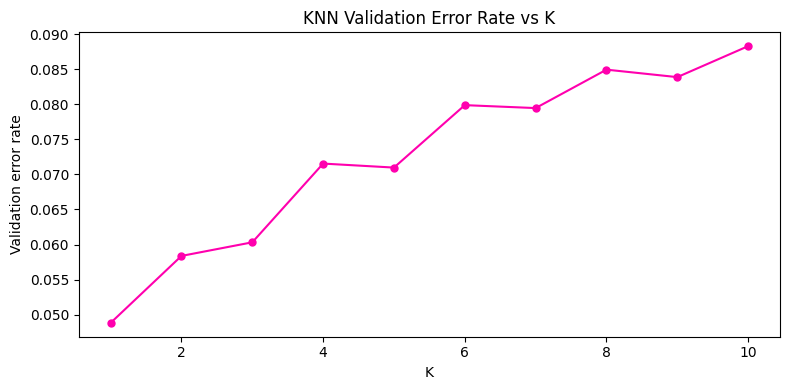


Best K according to validation error rate: K=1
KNN (K=1) - Train acc: 0.9772  Test acc: 0.9499
              precision    recall  f1-score   support

           0       0.97      0.97      0.97     21912
           1       0.72      0.71      0.72      2120

    accuracy                           0.95     24032
   macro avg       0.84      0.84      0.84     24032
weighted avg       0.95      0.95      0.95     24032


=== Overall classifier results so far ===
        model  train_acc  test_acc  relative_to_best
0  GaussianNB   0.855691  0.876623             0.923
1    KNN(K=1)   0.977226  0.949900             1.000



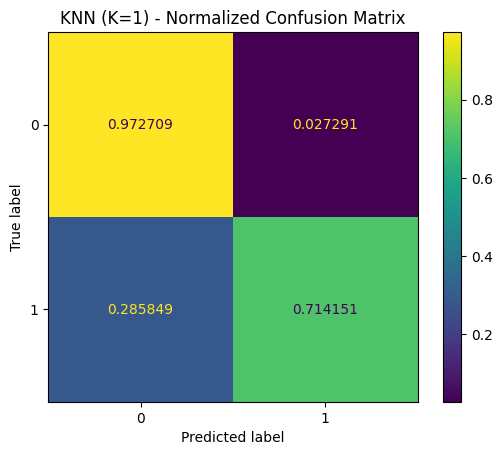

In [10]:
# ============================================================
# 10) K-Nearest Neighbors (with step-by-step progress)
# ============================================================

print("\n>>> Scanning KNN over K = 1..10")

X_knn_train, X_knn_val, Y_knn_train, Y_knn_val = train_test_split(
    Xtr, Ytr, random_state=42, test_size=0.2, stratify=Ytr
)

k_values = list(range(1, 11))
knn_c_acc = []

for k in k_values:
    clf = KNeighborsClassifier(n_neighbors=k).fit(X_knn_train, Y_knn_train)
    train_score = clf.score(X_knn_train, Y_knn_train)
    val_score = clf.score(X_knn_val, Y_knn_val)
    knn_c_acc.append((k, train_score, val_score))
    print(f"K={k:2d}  Train={train_score:.4f}  Validation={val_score:.4f}")

sc = pd.DataFrame(knn_c_acc, columns=["K", "Train Score", "Validation Score"])
print("\n=== KNN scores (all K) ===")
print(sc)

error_rate = []
for k in k_values:
    clf = KNeighborsClassifier(n_neighbors=k).fit(X_knn_train, Y_knn_train)
    y_val_pred = clf.predict(X_knn_val)
    error_rate.append(np.mean(Y_knn_val != y_val_pred))

plt.figure(figsize=(8, 4))
plt.plot(k_values, error_rate, marker="o", markersize=5, color="#FF00AE")
plt.xlabel("K")
plt.ylabel("Validation error rate")
plt.title("KNN Validation Error Rate vs K")
plt.tight_layout()
plt.show()

best_k_idx = int(np.argmin(error_rate))
best_k = k_values[best_k_idx]
print(f"\nBest K according to validation error rate: K={best_k}")

clf = KNeighborsClassifier(n_neighbors=best_k).fit(Xtr, Ytr)
y_pred = clf.predict(Xte)
train_acc = clf.score(Xtr, Ytr)
test_acc = clf.score(Xte, Yte)

print(f"KNN (K={best_k}) - Train acc: {train_acc:.4f}  Test acc: {test_acc:.4f}")
print(classification_report(Yte, y_pred, zero_division=0))

add_result(f"KNN(K={best_k})", train_acc, test_acc)
show_overall_progress()

cm = confusion_matrix(Yte, y_pred, labels=clf.classes_, normalize="true")
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(values_format="g")
plt.title(f"KNN (K={best_k}) - Normalized Confusion Matrix")
plt.show()


>>> Training SVM (RBF)...
SVM (RBF) - Train acc: 0.8938448900112574  Test acc: 0.8528212383488681
              precision    recall  f1-score   support

           0       0.99      0.85      0.91     21912
           1       0.37      0.92      0.52      2120

    accuracy                           0.85     24032
   macro avg       0.68      0.88      0.72     24032
weighted avg       0.94      0.85      0.88     24032


=== Overall classifier results so far ===
        model  train_acc  test_acc  relative_to_best
0  GaussianNB   0.855691  0.876623             0.923
1    KNN(K=1)   0.977226  0.949900             1.000
2   SVM (RBF)   0.893845  0.852821             0.898



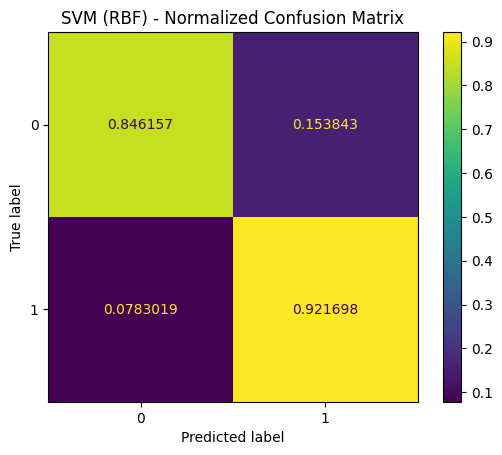

In [11]:
# ============================================================
# 11) SVM (RBF)
# ============================================================

print("\n>>> Training SVM (RBF)...")
clf = svm.SVC(kernel="rbf", gamma="scale").fit(Xtr, Ytr)
y_pred = clf.predict(Xte)
train_acc = clf.score(Xtr, Ytr)
test_acc = clf.score(Xte, Yte)

print("SVM (RBF) - Train acc:", train_acc, " Test acc:", test_acc)
print(classification_report(Yte, y_pred, zero_division=0))

add_result("SVM (RBF)", train_acc, test_acc)
show_overall_progress()

cm = confusion_matrix(Yte, y_pred, labels=clf.classes_, normalize="true")
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(values_format="g")
plt.title("SVM (RBF) - Normalized Confusion Matrix")
plt.show()


>>> Training Logistic Regression...
Logistic Regression - Train acc: 0.8697629841482338  Test acc: 0.8686334886817576
              precision    recall  f1-score   support

           0       0.98      0.87      0.92     21912
           1       0.39      0.86      0.54      2120

    accuracy                           0.87     24032
   macro avg       0.69      0.86      0.73     24032
weighted avg       0.93      0.87      0.89     24032


=== Overall classifier results so far ===
                 model  train_acc  test_acc  relative_to_best
0           GaussianNB   0.855691  0.876623             0.923
1             KNN(K=1)   0.977226  0.949900             1.000
2            SVM (RBF)   0.893845  0.852821             0.898
3  Logistic Regression   0.869763  0.868633             0.914



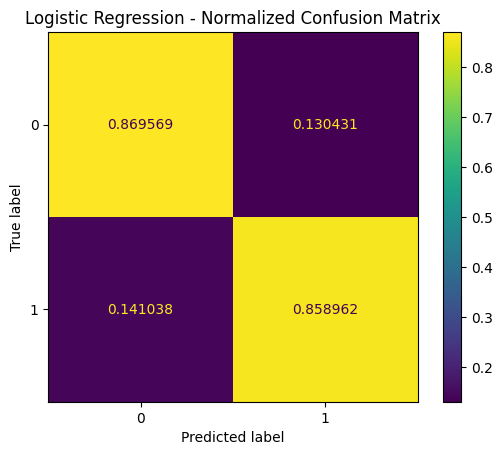

In [12]:
# ============================================================
# 12) Logistic Regression
# ============================================================

print("\n>>> Training Logistic Regression...")
clf = LogisticRegression(random_state=42, max_iter=1000).fit(Xtr, Ytr)
y_pred = clf.predict(Xte)
train_acc = clf.score(Xtr, Ytr)
test_acc = clf.score(Xte, Yte)

print("Logistic Regression - Train acc:", train_acc, " Test acc:", test_acc)
print(classification_report(Yte, y_pred, zero_division=0))

add_result("Logistic Regression", train_acc, test_acc)
show_overall_progress()

cm = confusion_matrix(Yte, y_pred, labels=clf.classes_, normalize="true")
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(values_format="g")
plt.title("Logistic Regression - Normalized Confusion Matrix")
plt.show()


>>> Training AdaBoost...
AdaBoost - Train acc: 0.9604694678552956  Test acc: 0.9528961384820239
              precision    recall  f1-score   support

           0       0.97      0.98      0.97     21912
           1       0.74      0.72      0.73      2120

    accuracy                           0.95     24032
   macro avg       0.86      0.85      0.85     24032
weighted avg       0.95      0.95      0.95     24032


=== Overall classifier results so far ===
                 model  train_acc  test_acc  relative_to_best
0           GaussianNB   0.855691  0.876623             0.920
1             KNN(K=1)   0.977226  0.949900             0.997
2            SVM (RBF)   0.893845  0.852821             0.895
3  Logistic Regression   0.869763  0.868633             0.912
4             AdaBoost   0.960469  0.952896             1.000



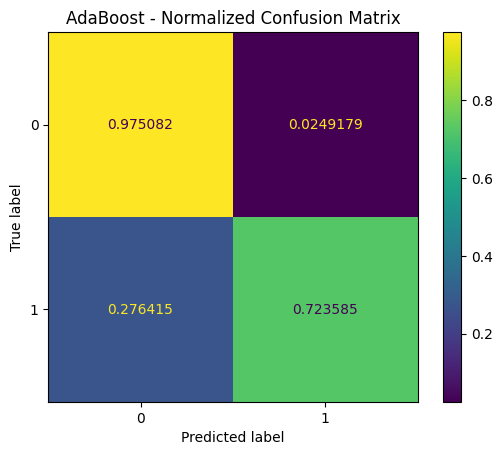

In [13]:
# ============================================================
# 13) AdaBoost
# ============================================================

print("\n>>> Training AdaBoost...")
clf = AdaBoostClassifier(n_estimators=500, random_state=42).fit(Xtr, Ytr)
y_pred = clf.predict(Xte)
train_acc = clf.score(Xtr, Ytr)
test_acc = clf.score(Xte, Yte)

print("AdaBoost - Train acc:", train_acc, " Test acc:", test_acc)
print(classification_report(Yte, y_pred, zero_division=0))

add_result("AdaBoost", train_acc, test_acc)
show_overall_progress()

cm = confusion_matrix(Yte, y_pred, labels=clf.classes_, normalize="true")
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(values_format="g")
plt.title("AdaBoost - Normalized Confusion Matrix")
plt.show()


>>> Training Decision Tree...
Decision Tree - Train acc: 0.9839048285514346  Test acc: 0.9675016644474035
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     21912
           1       0.93      0.69      0.79      2120

    accuracy                           0.97     24032
   macro avg       0.95      0.84      0.89     24032
weighted avg       0.97      0.97      0.97     24032


=== Overall classifier results so far ===
                 model  train_acc  test_acc  relative_to_best
0           GaussianNB   0.855691  0.876623             0.906
1             KNN(K=1)   0.977226  0.949900             0.982
2            SVM (RBF)   0.893845  0.852821             0.881
3  Logistic Regression   0.869763  0.868633             0.898
4             AdaBoost   0.960469  0.952896             0.985
5        Decision Tree   0.983905  0.967502             1.000



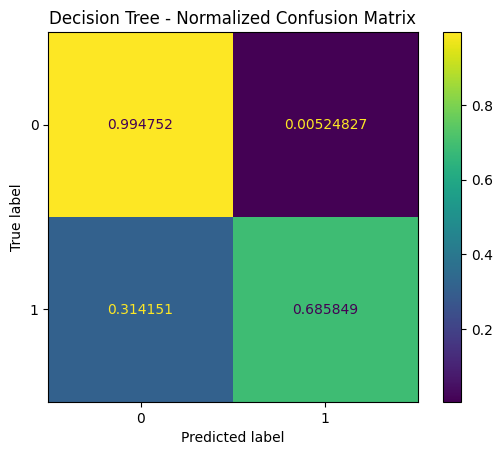

In [14]:
# ============================================================
# 14) Decision Tree
# ============================================================

print("\n>>> Training Decision Tree...")
clf = tree.DecisionTreeClassifier(random_state=42).fit(Xtr, Ytr)
y_pred = clf.predict(Xte)
train_acc = clf.score(Xtr, Ytr)
test_acc = clf.score(Xte, Yte)

print("Decision Tree - Train acc:", train_acc, " Test acc:", test_acc)
print(classification_report(Yte, y_pred, zero_division=0))

add_result("Decision Tree", train_acc, test_acc)
show_overall_progress()

cm = confusion_matrix(Yte, y_pred, labels=clf.classes_, normalize="true")
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(values_format="g")
plt.title("Decision Tree - Normalized Confusion Matrix")
plt.show()


>>> Training MLPClassifier...
MLPClassifier - Train acc: 0.9104877232482429  Test acc: 0.90021637816245
              precision    recall  f1-score   support

           0       0.98      0.91      0.94     21912
           1       0.46      0.84      0.60      2120

    accuracy                           0.90     24032
   macro avg       0.72      0.87      0.77     24032
weighted avg       0.94      0.90      0.91     24032


=== Overall classifier results so far ===
                 model  train_acc  test_acc  relative_to_best
0           GaussianNB   0.855691  0.876623             0.906
1             KNN(K=1)   0.977226  0.949900             0.982
2            SVM (RBF)   0.893845  0.852821             0.881
3  Logistic Regression   0.869763  0.868633             0.898
4             AdaBoost   0.960469  0.952896             0.985
5        Decision Tree   0.983905  0.967502             1.000
6        MLPClassifier   0.910488  0.900216             0.930



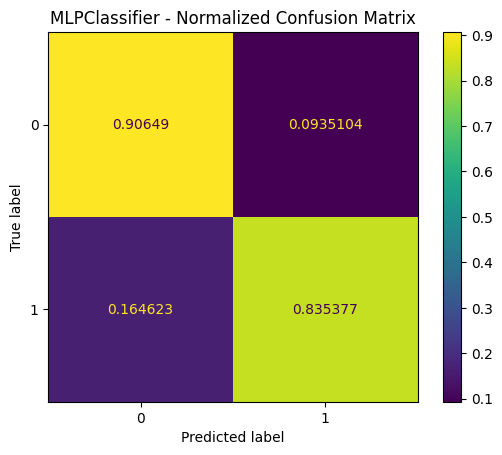

In [15]:
# ============================================================
# 15) MLPClassifier
# ============================================================

print("\n>>> Training MLPClassifier...")
clf = MLPClassifier(random_state=1, max_iter=300).fit(Xtr, Ytr)
y_pred = clf.predict(Xte)
train_acc = clf.score(Xtr, Ytr)
test_acc = clf.score(Xte, Yte)

print("MLPClassifier - Train acc:", train_acc, " Test acc:", test_acc)
print(classification_report(Yte, y_pred, zero_division=0))

add_result("MLPClassifier", train_acc, test_acc)
show_overall_progress()

cm = confusion_matrix(Yte, y_pred, labels=clf.classes_, normalize="true")
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(values_format="g")
plt.title("MLPClassifier - Normalized Confusion Matrix")
plt.show()

In [16]:
# ============================================================
# 16) Final summary
# ============================================================

print("\n=== FINAL CLASSIFIER SUMMARY ===")
show_overall_progress()
print("Done.")


=== FINAL CLASSIFIER SUMMARY ===

=== Overall classifier results so far ===
                 model  train_acc  test_acc  relative_to_best
0           GaussianNB   0.855691  0.876623             0.906
1             KNN(K=1)   0.977226  0.949900             0.982
2            SVM (RBF)   0.893845  0.852821             0.881
3  Logistic Regression   0.869763  0.868633             0.898
4             AdaBoost   0.960469  0.952896             0.985
5        Decision Tree   0.983905  0.967502             1.000
6        MLPClassifier   0.910488  0.900216             0.930

Done.
